In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

Load & Clean Data

In [3]:
df = pd.read_csv("sample.csv",encoding='latin1')   # latin1 handles special characters

# Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Handle missing values
df = df.dropna()

# Sort by date
df = df.sort_values('Order Date')

print("Data cleaned successfully")

Data cleaned successfully


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
7980,7981,CA-2014-103800,2014-01-03,1/7/2014,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
739,740,CA-2014-112326,2014-01-04,1/8/2014,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
740,741,CA-2014-112326,2014-01-04,1/8/2014,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
741,742,CA-2014-112326,2014-01-04,1/8/2014,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
1759,1760,CA-2014-141817,2014-01-05,1/12/2014,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


Feature Engineering (INCLUDING SEASONALITY)

In [5]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['DayOfWeek'] = df['Order Date'].dt.dayofweek

# Seasonality features
df['Quarter'] = df['Order Date'].dt.quarter
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

print("Feature engineering done")

Feature engineering done


Aggregate Sales (Time Series)

In [6]:
sales_data = df.groupby('Order Date')['Sales'].sum().reset_index()
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Year,Month,Day,DayOfWeek,Quarter,IsWeekend
7980,7981,CA-2014-103800,2014-01-03,1/7/2014,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,16.448,2,0.2,5.5512,2014,1,3,4,1,0
739,740,CA-2014-112326,2014-01-04,1/8/2014,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,11.784,3,0.2,4.2717,2014,1,4,5,1,1
740,741,CA-2014-112326,2014-01-04,1/8/2014,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,272.736,3,0.2,-64.7748,2014,1,4,5,1,1
741,742,CA-2014-112326,2014-01-04,1/8/2014,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,3.540,2,0.8,-5.4870,2014,1,4,5,1,1
1759,1760,CA-2014-141817,2014-01-05,1/12/2014,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19.536,3,0.2,4.8840,2014,1,5,6,1,1


Visualization (Trend and Seasonality Insight)

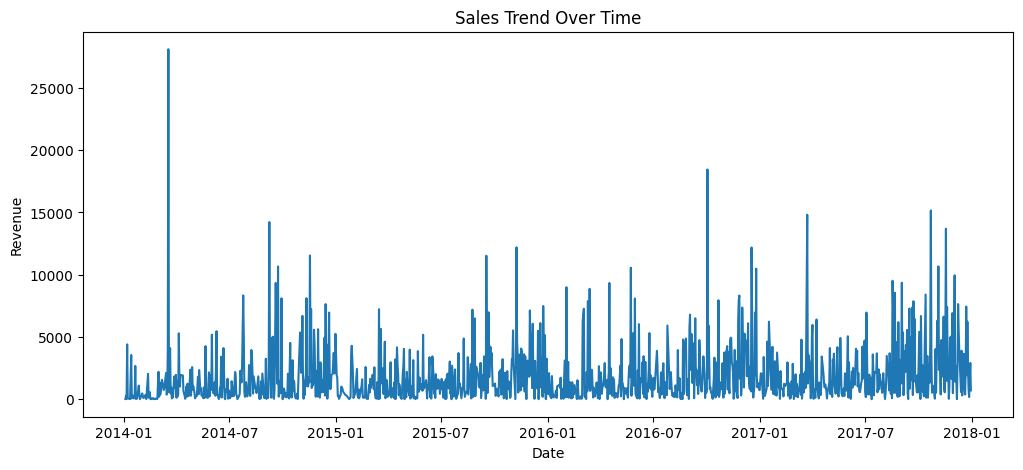

In [7]:
plt.figure(figsize=(12,5))
plt.plot(sales_data['Order Date'], sales_data['Sales'])

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

Prepare Data for Model

In [8]:
# Convert date into numeric format
sales_data['Date_ordinal'] = sales_data['Order Date'].map(pd.Timestamp.toordinal)

X = sales_data[['Date_ordinal']]
y = sales_data['Sales']

# Train-test split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

Train Model (Regression Forecasting)

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [10]:
# Predictions
y_pred = model.predict(X_test)

Model Evaluation (ERROR ANALYSIS)

In [11]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1794.174992880416
RMSE: 2456.217633051323


Forecasting Future Sales of Next 30 Days

In [12]:
future_dates = pd.date_range(start=sales_data['Order Date'].max(), periods=30)

future_ordinal = future_dates.map(pd.Timestamp.toordinal)

future_df = pd.DataFrame({'Date_ordinal':future_ordinal})

future_pred = model.predict(future_df)

Final Visualization

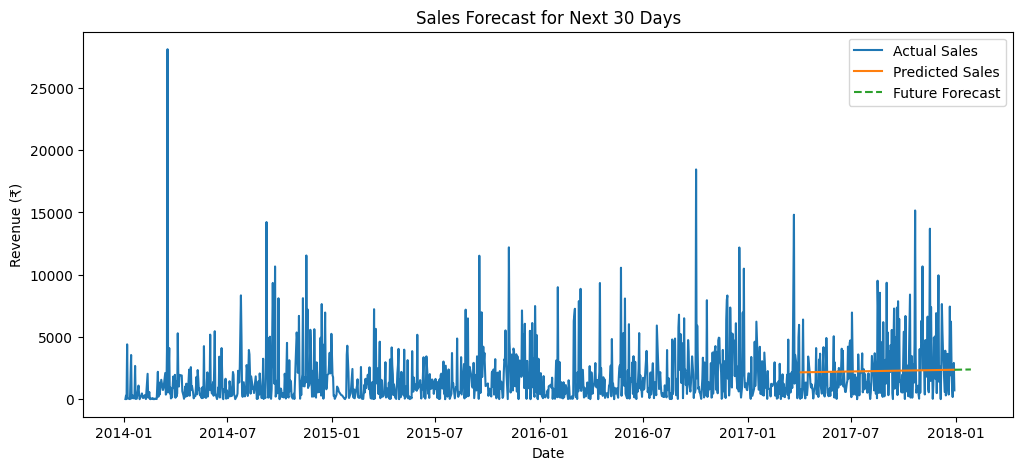

In [13]:
plt.figure(figsize=(12,5))

# Actual data
plt.plot(sales_data['Order Date'], sales_data['Sales'], label="Actual Sales")

# Predicted (test)
plt.plot(X_test['Date_ordinal'].map(pd.Timestamp.fromordinal), y_pred, label="Predicted Sales")

# Future forecast
plt.plot(future_dates, future_pred, label="Future Forecast", linestyle='dashed')

plt.title("Sales Forecast for Next 30 Days")
plt.xlabel("Date")
plt.ylabel("Revenue (₹)")
plt.legend()

plt.show()

* Sales/Demand Forecasting Model

A Machine Learning model using Linear Regression was built to predict future sales from historical data.
The dataset was cleaned, time-based features were created, and sales were aggregated for forecasting.
The model predicts sales for the next 30 days.

* Visualization of Predictions

Line graphs were used to show:

Actual sales (past data)
Predicted sales (model output)
Future forecast (next 30 days)

The graphs highlight trends, seasonal peaks, and expected future patterns.

* What the Forecast Means

The forecast estimates future sales based on past trends.
It shows growth patterns, seasonal demand, and whether sales may rise or fall.

* Business Use
* Plan inventory and avoid shortages
* Manage staff during high/low demand
* Estimate revenue and budget
* Plan marketing based on peak sales periods